# Marketing Funnel & Conversion Analysis

## Objective
Analyze user behavior across the eCommerce funnel (view → cart → purchase) to identify drop-off points, conversion rates, and opportunities to improve customer conversion.

## Import Libraries

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("talk")


## Load Dataset

In [21]:

df = pd.read_csv(r"C:\Users\Monwabisi05\IdeaProjects\DATA SCIENCE_FUTURE_DS_01\TASK_THREE\data_backup\2019-Oct.csv", nrows=100000)
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


## Data Overview

In [22]:
df.info()
df['event_type'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     100000 non-null  object 
 1   event_type     100000 non-null  object 
 2   product_id     100000 non-null  int64  
 3   category_id    100000 non-null  int64  
 4   category_code  67413 non-null   object 
 5   brand          85607 non-null   object 
 6   price          100000 non-null  float64
 7   user_id        100000 non-null  int64  
 8   user_session   100000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 6.9+ MB


event_type
view        97130
purchase     1655
cart         1215
Name: count, dtype: int64

## Data Preparation 

In [25]:
df['event_time'] = pd.to_datetime(df['event_time'])

## Funnel Definition

This analysis defines the funnel as:

View → Cart → Purchase

Where:
- View = product page visit
- Cart = user adds item to cart
- Purchase = completed transaction

## Funnel Counts

In [27]:
visitors = df[df['event_type'] == 'view']['user_id'].nunique()
leads = df[df['event_type'] == 'cart']['user_id'].nunique()
customers = df[df['event_type'] == 'purchase']['user_id'].nunique()

visitors, leads, customers

(20383, 743, 1336)

### Insight
The number of customers exceeds users who added items to cart, indicating that purchases may occur without a cart step.

## Convertion Rates

In [28]:
visit_to_cart = (leads / visitors) * 100
cart_to_purchase = (customers / leads) * 100
visit_to_purchase = (customers / visitors) * 100

visit_to_cart, cart_to_purchase, visit_to_purchase

(3.645194524849139, 179.81157469717363, 6.554481675906393)

### Insight
Visitor-to-cart conversion is very low (~3.6%), while overall purchase conversion is higher (~6.5%), suggesting non-linear user behavior.

## Drop-off Analysis

In [31]:
drop_off_rate = 100 - visit_to_purchase
drop_view_to_cart = 100 - visit_to_cart

drop_off_rate, drop_view_to_cart

(93.44551832409361, 96.35480547515085)

### Insight
A high drop-off rate (~93%) shows that most users leave without purchasing, with the largest loss occurring at the view stage.

## Price Analysis

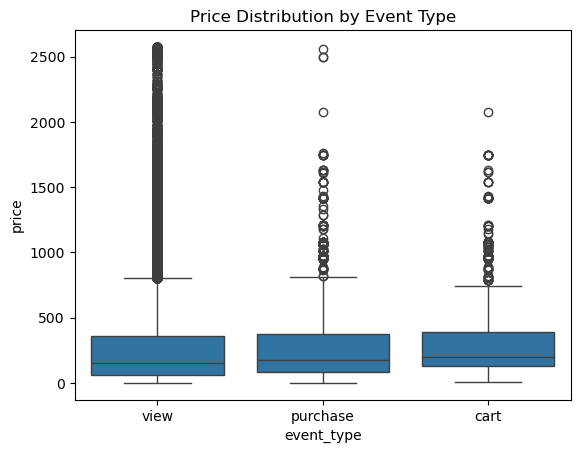

In [16]:
sns.boxplot(data=df, x='event_type', y='price')

plt.title("Price Distribution by Event Type")
plt.show()

### Insight
High-priced products receive significant views but show lower conversion, indicating price sensitivity among users.

## Catagory Analysis

In [17]:
category_conversion = df.groupby(['category_id', 'event_type'])['user_id'].nunique().unstack()

category_conversion.head()

event_type,cart,purchase,view
category_id,,,
2053013552226107603,NaN,NaN,2.0
2053013552259662037,NaN,12.0,144.0
2053013552293216471,3.0,13.0,215.0
2053013552326770905,2.0,5.0,101.0
2053013552351936731,NaN,1.0,37.0


### Insight
Conversion performance varies across categories, with some categories generating purchases more efficiently than others.

## Key Insights

- High drop-off rate (~93%) indicates low conversion efficiency
- Majority of users do not progress beyond the viewing stage
- Purchase behavior does not strictly depend on cart activity
- High-priced products attract attention but convert less
- Conversion performance varies significantly across product categories

## Recommendations

- Improve product pages to increase add-to-cart actions
- Optimize pricing strategy for high-value products
- Focus marketing efforts on high-converting categories
- Simplify purchase process to support direct conversions
- Enhance user experience to reduce early-stage drop-off

## Conclusion

This analysis highlights key inefficiencies in the conversion funnel, particularly at the early stages. By addressing user engagement, pricing perception, and category performance, businesses can improve conversion rates and drive revenue growth.